# Reconstruction Validation

This notebook evaluates CAML-style compression fidelity for SLformer cross-attention embeddings. The focus is classification preservation: after compressing the 1024D pair embedding to 24 PCA dimensions, how much AUROC, AUPRC, F1, and Precision@P are lost under the benchmark split scenarios used by SLformer?

In [1]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, f1_score, precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

mpl.rcParams.update({
    "font.family": "sans-serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

print("Project root:", PROJECT_ROOT)

Project root: /home/guoyu/SLformer_interpretation


## Scenario Definition

The SLformer paper benchmarks three settings: Cancer-specific, Mixed-cancer, and Cross-cancer leave-one-cancer-out. The local split files reproduce these settings over the original eight benchmark cancers. Here we use the `*_all` split directories because they cover the same 58,620 benchmark rows aligned to the available SLformer cross-attention embeddings.

The available per-row score $s_i$ is the mixed-cancer SLformer prediction score from the local aligned prediction CSVs. We train XGBoost score probes to approximate $s_i$ from either full embeddings or 24D PCA coordinates, but evaluate only classification metrics against binary labels $y_i$. Continuous-score fidelity is not used for the conclusion.

In [2]:
SEED = 42
N_COMPONENTS = 24
CANCERS = ["KIRC", "COAD", "LAML", "OV", "BRCA", "CESC", "SKCM", "LUAD"]

EMBEDDINGS_PKL = PROJECT_ROOT / "data" / "all_SL" / "mix_slformer_kg_crossemb.pkl"
PREDICTION_CSVS = [PROJECT_ROOT / "data" / "all_SL" / f"pred_mix_slformer_kg_cv{fold}.csv" for fold in range(1, 6)]
LABEL_CSVS = [PROJECT_ROOT / "data" / "merged_pred_true_slformer" / f"merged_pred_true_fold_{fold}.csv" for fold in range(1, 6)]
GENE2ID_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "gene2id.pkl"
CANCER_LIST_TXT = PROJECT_ROOT / "data" / "saved_data" / "map" / "cancer_list.txt"
SPLIT_ROOT = PROJECT_ROOT / "data" / "saved_data" / "SL_train_test_data"

xgb_params = {
    "objective": "reg:squarederror",
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": 8,
}

print({
    "compressed_dim": N_COMPONENTS,
    "benchmark_cancers": CANCERS,
    "xgb_n_estimators": xgb_params["n_estimators"],
})

{'compressed_dim': 24, 'benchmark_cancers': ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD'], 'xgb_n_estimators': 200}


## Load Benchmark Embeddings

For each row $i$, the pair embedding is

$$
X_i = [h_{A|B}; h_{B|A}] \in \mathbb{R}^{1024},
$$

where each half is a 512D cross-attention embedding. Metadata and labels are aligned by `(primary_gene, partner_gene, cancer)`. Gene and cancer IDs are added so the original split arrays can be mapped back to embedding rows exactly.

In [3]:
with EMBEDDINGS_PKL.open("rb") as f:
    embedding_folds = pickle.load(f)

X = np.concatenate(
    [np.concatenate([fold[0], fold[1]], axis=1) for fold in embedding_folds],
    axis=0,
).astype(np.float32)

pred = pd.concat(
    [pd.read_csv(path).assign(pred_fold=fold) for fold, path in enumerate(PREDICTION_CSVS, start=1)],
    ignore_index=True,
)
label_table = pd.concat([pd.read_csv(path) for path in LABEL_CSVS], ignore_index=True).reset_index(drop=True)
label_table = label_table.rename(columns={"gene1": "primary_gene", "gene2": "partner_gene", "pred_score": "label_file_score"})

meta = pred.merge(
    label_table[["primary_gene", "partner_gene", "cancer", "label", "label_file_score"]],
    on=["primary_gene", "partner_gene", "cancer"],
    how="left",
)
meta["score_abs_diff"] = (meta["score"] - meta["label_file_score"]).abs()

with GENE2ID_PKL.open("rb") as f:
    gene2id = pickle.load(f)
cancer_names = [line.strip() for line in CANCER_LIST_TXT.open() if line.strip()]
cancer2id = {cancer: index for index, cancer in enumerate(cancer_names)}

meta["gene1_id"] = meta["primary_gene"].map(gene2id).astype(int)
meta["gene2_id"] = meta["partner_gene"].map(gene2id).astype(int)
meta["cancer_id"] = meta["cancer"].map(cancer2id).astype(int)
meta["label"] = meta["label"].astype(int)

row_index = {
    (int(row.gene1_id), int(row.gene2_id), int(row.cancer_id)): i
    for i, row in enumerate(meta.itertuples(index=False))
}

alignment_summary = pd.DataFrame([
    {"quantity": "embedding rows", "value": X.shape[0]},
    {"quantity": "embedding dimension", "value": X.shape[1]},
    {"quantity": "metadata rows", "value": len(meta)},
    {"quantity": "missing labels", "value": int(meta["label"].isna().sum())},
    {"quantity": "duplicate split keys", "value": int(meta.duplicated(["gene1_id", "gene2_id", "cancer_id"]).sum())},
    {"quantity": "max score mismatch", "value": float(meta["score_abs_diff"].max())},
    {"quantity": "positive fraction", "value": float(meta["label"].mean())},
])
display(alignment_summary)
display(meta[["primary_gene", "partner_gene", "cancer", "label", "score", "pred_fold"]].head())

,quantity,value
0,embedding rows,58620.000000
1,embedding dimension,1024.000000
2,metadata rows,58620.000000
3,missing labels,0.000000
4,duplicate split keys,0.000000
5,max score mismatch,0.000000
6,positive fraction,0.043091


,primary_gene,partner_gene,cancer,label,score,pred_fold
0,AKT1,BCL2,KIRC,0,0.000425,1
1,PTEN,RUNX1,KIRC,0,0.001516,1
2,HDAC6,SMARCA4,KIRC,0,0.005020,1
3,ARID1A,PIK3R1,KIRC,0,0.000929,1
4,BRCA1,HDAC1,KIRC,0,0.015028,1


## Split Mapping

Each original split file contains rows `(gene1_id, gene2_id, label, cancer_id)`. We map those keys to row indices in the aligned embedding matrix. This lets the compression probe use the same train/test partitions as the paper scenarios.

In [4]:
def indices_from_split_array(arr: np.ndarray) -> np.ndarray:
    return np.asarray(
        [row_index[(int(gene1), int(gene2), int(cancer))] for gene1, gene2, label, cancer in arr],
        dtype=int,
    )

scenario_rows = []

for fold in range(1, 6):
    scenario_rows.append({
        "scenario": "Mixed-cancer CV",
        "cancer": "all",
        "repeat": f"fold {fold}",
        "train_path": SPLIT_ROOT / "mix_all" / f"train_all_fold_{fold}.npy",
        "test_path": SPLIT_ROOT / "mix_all" / f"test_all_fold_{fold}.npy",
    })

for cancer in CANCERS:
    for fold in range(1, 6):
        scenario_rows.append({
            "scenario": "Cancer-specific CV",
            "cancer": cancer,
            "repeat": f"fold {fold}",
            "train_path": SPLIT_ROOT / "cancer_specific_all" / f"train_{cancer}_fold_{fold}.npy",
            "test_path": SPLIT_ROOT / "cancer_specific_all" / f"test_{cancer}_fold_{fold}.npy",
        })

for cancer in CANCERS:
    scenario_rows.append({
        "scenario": "Cross-cancer LOO",
        "cancer": cancer,
        "repeat": "leave-out",
        "train_path": SPLIT_ROOT / "cross_cancer_all" / f"train_{cancer}.npy",
        "test_path": SPLIT_ROOT / "cross_cancer_all" / f"test_{cancer}.npy",
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_table["train_n"] = [len(np.load(path)) for path in scenario_table["train_path"]]
scenario_table["test_n"] = [len(np.load(path)) for path in scenario_table["test_path"]]
display(scenario_table.groupby("scenario")[["train_n", "test_n"]].agg(["count", "min", "median", "max"]))

train_n                        test_n                  \
                     count    min   median    max  count    min   median   
scenario                                                                   
Cancer-specific CV      40    204   2543.0  23840     40     51    635.0   
Cross-cancer LOO         8  28359  52650.5  58354      8    255   3179.0   
Mixed-cancer CV          5  46893  46893.0  46908      5  11712  11727.0   

                           
                      max  
scenario                   
Cancer-specific CV   5960  
Cross-cancer LOO    29797  
Mixed-cancer CV     11727

## Classification Metrics

All probes output continuous scores and are evaluated as ranking classifiers. For a test set with labels $y$ and score vector $p$, we report:

$$
\mathrm{AUROC}(y,p), \quad \mathrm{AUPRC}(y,p), \quad \mathrm{Precision@P}(y,p),
$$

where $P=\sum_i y_i$. We also report $F1@\pi_{train}$ by predicting as positive the top $\pi_{train}$ fraction of test rows, where $\pi_{train}$ is the training positive fraction. This avoids arbitrary score thresholds while preserving a classification interpretation.

In [5]:
def classification_metrics(y_true: np.ndarray, scores: np.ndarray, train_positive_fraction: float) -> dict[str, float]:
    y_true = y_true.astype(int)
    scores = scores.astype(float)
    positive_count = int(y_true.sum())
    order = np.argsort(-scores)

    p_count = int(round(float(train_positive_fraction) * len(y_true)))
    p_count = max(1, min(p_count, len(y_true)))
    y_pred = np.zeros(len(y_true), dtype=int)
    y_pred[order[:p_count]] = 1

    metrics = {
        "AUROC": roc_auc_score(y_true, scores) if np.unique(y_true).size == 2 else np.nan,
        "AUPRC": average_precision_score(y_true, scores) if positive_count > 0 else np.nan,
        "F1@train_prevalence": f1_score(y_true, y_pred) if positive_count > 0 else np.nan,
        "Precision@P": float(y_true[order[:positive_count]].mean()) if positive_count > 0 else np.nan,
    }
    return metrics

## Run Compression Probes

For each benchmark split, we fit train-only preprocessing and two XGBoost score probes:

$$
\hat{s}^{full} = f_{1024}(\tilde{X}), \qquad \hat{s}^{24} = f_{24}(Z_{24}),
$$

where $Z_{24}$ is a PCA projection fit only on the training rows. The target for both probes is the original SLformer score $s$, but the evaluation below is strictly classification-based against $y$.

In [6]:
scores = meta["score"].to_numpy(dtype=np.float32)
labels = meta["label"].to_numpy(dtype=int)

result_rows = []
variance_rows = []

for scenario in scenario_rows:
    train_arr = np.load(scenario["train_path"])
    test_arr = np.load(scenario["test_path"])
    train_idx = indices_from_split_array(train_arr)
    test_idx = indices_from_split_array(test_arr)

    y_train = labels[train_idx]
    y_test = labels[test_idx]
    s_train = scores[train_idx]
    s_test = scores[test_idx]
    train_positive_fraction = float(y_train.mean())

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[train_idx]).astype(np.float32)
    X_test = scaler.transform(X[test_idx]).astype(np.float32)

    pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
    Z_train = pca.fit_transform(X_train).astype(np.float32)
    Z_test = pca.transform(X_test).astype(np.float32)

    full_probe = XGBRegressor(**xgb_params)
    pca_probe = XGBRegressor(**xgb_params)
    full_probe.fit(X_train, s_train)
    pca_probe.fit(Z_train, s_train)

    predictions = {
        "Original mixed SLformer score": s_test,
        "XGB full embedding": full_probe.predict(X_test).astype(np.float32),
        "XGB PCA24": pca_probe.predict(Z_test).astype(np.float32),
    }

    for model_name, pred_scores in predictions.items():
        row = {
            "scenario": scenario["scenario"],
            "cancer": scenario["cancer"],
            "repeat": scenario["repeat"],
            "model": model_name,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_positive_fraction": train_positive_fraction,
            "test_positive_fraction": float(y_test.mean()),
        }
        row.update(classification_metrics(y_test, pred_scores, train_positive_fraction))
        result_rows.append(row)

    variance_rows.append({
        "scenario": scenario["scenario"],
        "cancer": scenario["cancer"],
        "repeat": scenario["repeat"],
        "PCA24_explained_variance": float(pca.explained_variance_ratio_.sum()),
    })

results = pd.DataFrame(result_rows)
pca_variance = pd.DataFrame(variance_rows)

display(results.head())
display(pca_variance.groupby("scenario")["PCA24_explained_variance"].agg(["mean", "std", "min", "max"]).round(4))

,scenario,cancer,repeat,model,train_n,test_n,train_positive_fraction,test_positive_fraction,AUROC,AUPRC,F1@train_prevalence,Precision@P
0,Mixed-cancer CV,all,fold 1,Original mixed SLformer score,46893,11727,0.042842,0.044086,0.775771,0.371517,0.384691,0.384913
1,Mixed-cancer CV,all,fold 1,XGB full embedding,46893,11727,0.042842,0.044086,0.567801,0.058552,0.072620,0.075435
2,Mixed-cancer CV,all,fold 1,XGB PCA24,46893,11727,0.042842,0.044086,0.559160,0.058925,0.082434,0.083172
3,Mixed-cancer CV,all,fold 2,Original mixed SLformer score,46893,11727,0.043290,0.042296,0.767700,0.365155,0.368526,0.372984
4,Mixed-cancer CV,all,fold 2,XGB full embedding,46893,11727,0.043290,0.042296,0.527570,0.047885,0.057769,0.058468


,mean,std,min,max
scenario,,,,
Cancer-specific CV,0.5173,0.0830,0.3711,0.6387
Cross-cancer LOO,0.4652,0.0153,0.4403,0.4941
Mixed-cancer CV,0.4686,0.0093,0.4554,0.4779


## Compression Drops

The primary compression loss is measured as

$$
\Delta m = m(\mathrm{PCA24}) - m(\mathrm{FullEmbedding}),
$$

for each classification metric $m$. Negative values mean information loss after 24D compression. The original mixed SLformer score is retained as a reference, but the scenario-specific compression claim is the full-vs-PCA24 drop.

In [7]:
metric_cols = ["AUROC", "AUPRC", "F1@train_prevalence", "Precision@P"]
index_cols = ["scenario", "cancer", "repeat"]

wide = results.pivot_table(index=index_cols, columns="model", values=metric_cols).reset_index()
wide.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in wide.columns]

for metric in metric_cols:
    wide[f"delta_{metric}_PCA24_minus_full"] = wide[f"{metric}_XGB PCA24"] - wide[f"{metric}_XGB full embedding"]
    wide[f"delta_{metric}_PCA24_minus_original"] = wide[f"{metric}_XGB PCA24"] - wide[f"{metric}_Original mixed SLformer score"]

summary_rows = []
for scenario_name, group in wide.groupby("scenario"):
    row = {"scenario": scenario_name, "n_repeats": len(group)}
    for metric in metric_cols:
        row[f"full_{metric}"] = group[f"{metric}_XGB full embedding"].mean()
        row[f"pca24_{metric}"] = group[f"{metric}_XGB PCA24"].mean()
        row[f"drop_{metric}"] = group[f"delta_{metric}_PCA24_minus_full"].mean()
    summary_rows.append(row)
scenario_summary = pd.DataFrame(summary_rows)

drop_by_cancer = (
    wide.groupby(["scenario", "cancer"])[[f"delta_{metric}_PCA24_minus_full" for metric in metric_cols]]
    .mean()
    .reset_index()
)

display(scenario_summary.round(4))
display(drop_by_cancer.round(4))

,scenario,n_repeats,full_AUROC,pca24_AUROC,drop_AUROC,full_AUPRC,pca24_AUPRC,drop_AUPRC,full_F1@train_prevalence,pca24_F1@train_prevalence,drop_F1@train_prevalence,full_Precision@P,pca24_Precision@P,drop_Precision@P
0,Cancer-specific CV,40,0.5410,0.5163,-0.0247,0.1709,0.1563,-0.0146,0.1628,0.1366,-0.0262,0.1673,0.1377,-0.0296
1,Cross-cancer LOO,8,0.6631,0.6142,-0.0489,0.2621,0.2140,-0.0480,0.1170,0.1080,-0.0090,0.2613,0.2273,-0.0339
2,Mixed-cancer CV,5,0.5075,0.5407,0.0332,0.0457,0.0535,0.0078,0.0475,0.0708,0.0233,0.0483,0.0702,0.0219


,scenario,cancer,delta_AUROC_PCA24_minus_full,delta_AUPRC_PCA24_minus_full,delta_F1@train_prevalence_PCA24_minus_full,delta_Precision@P_PCA24_minus_full
0,Cancer-specific CV,BRCA,-0.1631,-0.0985,-0.1276,-0.1389
1,Cancer-specific CV,CESC,0.0810,0.0069,-0.0093,-0.0018
2,Cancer-specific CV,COAD,-0.0056,-0.0022,-0.0163,-0.0175
3,Cancer-specific CV,KIRC,0.0021,0.0594,0.0489,0.0029
4,Cancer-specific CV,LAML,0.0030,0.0008,0.0028,0.0068
5,Cancer-specific CV,LUAD,-0.1017,-0.0406,-0.0429,-0.0386
6,Cancer-specific CV,OV,-0.0143,-0.0327,-0.0502,-0.0293
7,Cancer-specific CV,SKCM,0.0011,-0.0102,-0.0153,-0.0202
8,Cross-cancer LOO,BRCA,-0.1695,-0.1953,-0.0475,-0.1250
9,Cross-cancer LOO,CESC,-0.0076,-0.0029,0.0214,0.0250


## Classification Preservation Plots

The first figure compares full-embedding and PCA24 probes across the three benchmark scenarios. The second figure shows per-cancer compression drops for AUPRC and Precision@P, the two metrics most sensitive to class imbalance.

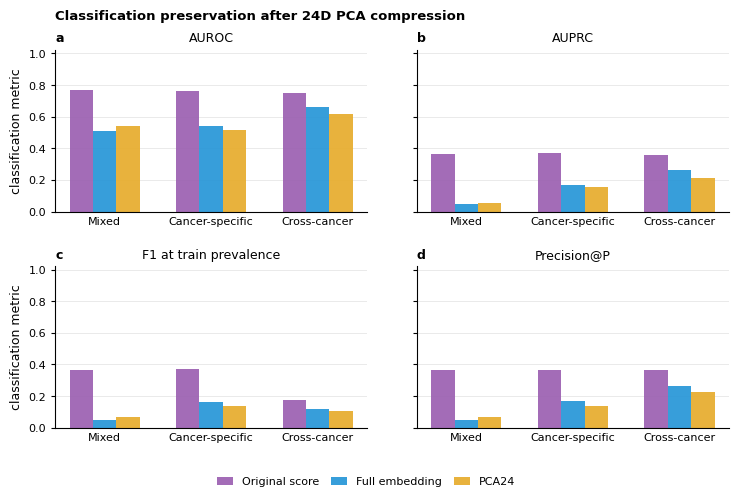

In [8]:
okabe_ito = {
    "blue": "#2696D7",
    "sky": "#56B4E9",
    "orange": "#E7AC2C",
    "green": "#009E73",
    "purple": "#9B60B1",
    "light_gray": "#D9D9D9",
}
scenario_order = ["Mixed-cancer CV", "Cancer-specific CV", "Cross-cancer LOO"]
scenario_labels = ["Mixed", "Cancer-specific", "Cross-cancer"]
model_order = ["Original mixed SLformer score", "XGB full embedding", "XGB PCA24"]
model_labels = {
    "Original mixed SLformer score": "Original score",
    "XGB full embedding": "Full embedding",
    "XGB PCA24": "PCA24",
}
model_colors = {
    "Original mixed SLformer score": okabe_ito["purple"],
    "XGB full embedding": okabe_ito["blue"],
    "XGB PCA24": okabe_ito["orange"],
}
metric_labels = {
    "AUROC": "AUROC",
    "AUPRC": "AUPRC",
    "F1@train_prevalence": "F1 at train prevalence",
    "Precision@P": "Precision@P",
}

mean_metrics = (
    results.groupby(["scenario", "model"])[metric_cols]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.1), sharey=True, constrained_layout=False)
axes = axes.ravel()
bar_width = 0.22
x = np.arange(len(scenario_order))
panel_ids = ["a", "b", "c", "d"]
for ax, metric, panel_id in zip(axes, metric_cols, panel_ids):
    for offset, model_name in zip([-bar_width, 0.0, bar_width], model_order):
        values = [
            float(
                mean_metrics[
                    (mean_metrics["scenario"] == scenario_name)
                    & (mean_metrics["model"] == model_name)
                ][metric].iloc[0]
            )
            for scenario_name in scenario_order
        ]
        ax.bar(
            x + offset,
            values,
            width=bar_width,
            color=model_colors[model_name],
            label=model_labels[model_name],
            linewidth=0,
            alpha=0.92,
        )
    ax.set_title(panel_id, loc="left", fontweight="bold", fontsize=9)
    ax.set_title(metric_labels[metric], loc="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels)
    ax.set_ylim(0.0, 1.02)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=3)
    ax.grid(axis="y", color=okabe_ito["light_gray"], linewidth=0.55, alpha=0.70)
    ax.set_axisbelow(True)
for ax in axes[::2]:
    ax.set_ylabel("classification metric")

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(left=0.08, right=0.99, top=0.90, bottom=0.16, wspace=0.16, hspace=0.34)
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.025),
    ncol=3,
    frameon=False,
    handlelength=1.4,
    columnspacing=1.1,
)
fig.suptitle("Classification preservation after 24D PCA compression", x=0.08, y=0.98, ha="left", fontsize=9.5, fontweight="bold")
plt.show()


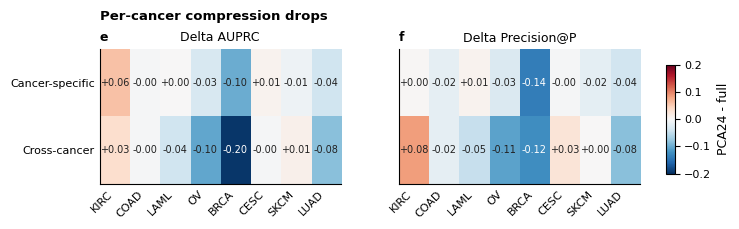

In [9]:
plot_drop = drop_by_cancer[drop_by_cancer["cancer"] != "all"].copy()
plot_drop["scenario"] = pd.Categorical(plot_drop["scenario"], categories=scenario_order, ordered=True)
plot_drop = plot_drop.sort_values(["scenario", "cancer"])

heat_metrics = ["delta_AUPRC_PCA24_minus_full", "delta_Precision@P_PCA24_minus_full"]
heat_titles = ["Delta AUPRC", "Delta Precision@P"]
heat_scenarios = ["Cancer-specific CV", "Cross-cancer LOO"]
heat_scenario_labels = ["Cancer-specific", "Cross-cancer"]
heat_matrices = [
    plot_drop.pivot(index="scenario", columns="cancer", values=metric).loc[heat_scenarios, CANCERS]
    for metric in heat_metrics
]
heat_limit = max(float(np.nanmax(np.abs(matrix.to_numpy()))) for matrix in heat_matrices)
heat_limit = float(np.ceil(heat_limit / 0.01) * 0.01)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.6), constrained_layout=False)
for ax, matrix, title, panel_id in zip(axes, heat_matrices, heat_titles, ["e", "f"]):
    im = ax.imshow(matrix.to_numpy(), cmap="RdBu_r", vmin=-heat_limit, vmax=heat_limit, aspect="auto")
    ax.set_title(panel_id, loc="left", fontweight="bold", fontsize=9)
    ax.set_title(title, loc="center", fontsize=9)
    ax.set_xticks(np.arange(len(CANCERS)))
    ax.set_xticklabels(CANCERS, rotation=45, ha="right")
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.tick_params(axis="both", length=0)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = float(matrix.iloc[i, j])
            text_color = "white" if abs(value) > 0.55 * heat_limit else "#222222"
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=7, color=text_color)
axes[0].set_yticklabels(heat_scenario_labels)
axes[1].set_yticklabels([])
axes[1].tick_params(labelleft=False)

fig.subplots_adjust(left=0.16, right=0.89, top=0.82, bottom=0.30, wspace=0.24)
cbar_ax = fig.add_axes([0.925, 0.34, 0.012, 0.42])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("PCA24 - full")
fig.suptitle("Per-cancer compression drops", x=0.16, y=0.97, ha="left", fontsize=9.5, fontweight="bold")
plt.show()


## Compact Tables For Reporting

The table below keeps only classification drops. The manuscript-facing number is the full-vs-PCA24 delta; the original mixed SLformer score is a reference for the available mixed-model score vector, not a substitute for per-scenario SLformer checkpoints.

In [10]:
report_cols = [
    "scenario", "n_repeats",
    "full_AUROC", "pca24_AUROC", "drop_AUROC",
    "full_AUPRC", "pca24_AUPRC", "drop_AUPRC",
    "full_F1@train_prevalence", "pca24_F1@train_prevalence", "drop_F1@train_prevalence",
    "full_Precision@P", "pca24_Precision@P", "drop_Precision@P",
]
display(scenario_summary[report_cols].round(4))

worst_drops = drop_by_cancer[drop_by_cancer["cancer"] != "all"].copy()
worst_drops = worst_drops.sort_values("delta_AUPRC_PCA24_minus_full")
display(worst_drops.head(8).round(4))

,scenario,n_repeats,full_AUROC,pca24_AUROC,drop_AUROC,full_AUPRC,pca24_AUPRC,drop_AUPRC,full_F1@train_prevalence,pca24_F1@train_prevalence,drop_F1@train_prevalence,full_Precision@P,pca24_Precision@P,drop_Precision@P
0,Cancer-specific CV,40,0.5410,0.5163,-0.0247,0.1709,0.1563,-0.0146,0.1628,0.1366,-0.0262,0.1673,0.1377,-0.0296
1,Cross-cancer LOO,8,0.6631,0.6142,-0.0489,0.2621,0.2140,-0.0480,0.1170,0.1080,-0.0090,0.2613,0.2273,-0.0339
2,Mixed-cancer CV,5,0.5075,0.5407,0.0332,0.0457,0.0535,0.0078,0.0475,0.0708,0.0233,0.0483,0.0702,0.0219


,scenario,cancer,delta_AUROC_PCA24_minus_full,delta_AUPRC_PCA24_minus_full,delta_F1@train_prevalence_PCA24_minus_full,delta_Precision@P_PCA24_minus_full
8,Cross-cancer LOO,BRCA,-0.1695,-0.1953,-0.0475,-0.1250
14,Cross-cancer LOO,OV,-0.0918,-0.1046,-0.0211,-0.1071
0,Cancer-specific CV,BRCA,-0.1631,-0.0985,-0.1276,-0.1389
13,Cross-cancer LOO,LUAD,-0.0486,-0.0842,-0.0367,-0.0842
5,Cancer-specific CV,LUAD,-0.1017,-0.0406,-0.0429,-0.0386
12,Cross-cancer LOO,LAML,-0.0553,-0.0392,-0.0431,-0.0460
6,Cancer-specific CV,OV,-0.0143,-0.0327,-0.0502,-0.0293
7,Cancer-specific CV,SKCM,0.0011,-0.0102,-0.0153,-0.0202
